In [1]:
import os, glob, re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
# add your own file path here 
aria_FILE_PATH = '/Users/ernyk/OneDrive - National University of Singapore/nus/bt4241/bt4241 proj ideas/BT4241-2510-Project/final-project-code/did-by-country/ARIA Year End Charts' 
billboard_FILE_PATH = '/Users/ernyk/OneDrive - National University of Singapore/nus/bt4241/bt4241 proj ideas/BT4241-2510-Project/final-project-code/did-by-country/Billboard Year End Charts'

# audio features to consider
columns_to_read = ['BPM', 'Dance', 'Energy', 'Happy']
covariates = ["GDP_growth"] 

# create panel dataframe
chart_panel_df = pd.DataFrame(columns=['Country', 'Treat_Grp', 'Year', 'post_recession', 'BPM', 'Dance', 'Energy', 'Happy'])

### data merging
macroeconomic data processing

In [3]:
# set columns to read from macroeconomic data
def set_time_period(start, end):
    years = list(map(str, list(range(start, end))))
    li = ["Country Code"]
    li.extend(years)
    return years, li

years, li = set_time_period(2003, 2014)

# read macroeconomic data
def read_data(csv_name, col_list):
    stats_df = pd.read_csv(csv_name, usecols=col_list)

    # filter for australian and US data
    stats_df.loc[(stats_df['Country Code'] == 'AUS') | (stats_df['Country Code'] == 'USA')]

    #drop first column (used for calculation)
    #stats_df.drop([first_col], axis=1)
    return stats_df

gdp_stats_df = read_data("gdp_growth.csv", li)

first_col = "2003"

gdp_stats_df.drop([first_col], axis=1)
covariate_data = [gdp_stats_df]
    

joining macroeconomic statistics data with song data 

In [4]:
# building the aria statistics first
all_files = os.listdir(aria_FILE_PATH)
for filename in all_files:
    year = re.split(r'[ .]', filename)[-2]
    curr_year_csv = pd.read_csv(os.path.join(aria_FILE_PATH, filename), usecols=columns_to_read)
    median_audio_features = curr_year_csv.mean()
    #if year == '2012' or year == '2013' or year == '2004' or year == '2005':
    #    continue
    post_recession = 0 if int(year) < 2008 else 1
    new_row_df = pd.DataFrame({
        'Country': ['AUS'], 
        'Treat_Grp': [0],
        'Year': [int(year)], 
        'GDP_growth': gdp_stats_df.at[13, year],
        'post_recession': [post_recession], 
        'BPM': [median_audio_features['BPM']], 
        'Dance': [median_audio_features['Dance']], 
        'Energy': [median_audio_features['Energy']],
        'Happy': [median_audio_features['Happy']]
    })
    chart_panel_df = pd.concat([chart_panel_df, new_row_df], ignore_index=True)

# building the billboard statistics now
all_files = os.listdir(billboard_FILE_PATH)
for filename in all_files:
    year = filename.split()[0]
    curr_year_csv = pd.read_csv(os.path.join(billboard_FILE_PATH, filename), usecols=columns_to_read)
    median_audio_features = curr_year_csv.mean()
    post_recession = 0 if int(year) < 2008 else 1
    new_row_df = pd.DataFrame({
        'Country': ['USA'], 
        'Treat_Grp': [1],
        'Year': [int(year)],
        'GDP_growth': gdp_stats_df.at[251, year], 
        'post_recession': [post_recession], 
        'BPM': [median_audio_features['BPM']], 
        'Dance': [median_audio_features['Dance']], 
        'Energy': [median_audio_features['Energy']],
        'Happy': [median_audio_features['Happy']]
    })
    chart_panel_df = pd.concat([chart_panel_df, new_row_df], ignore_index=True)

C:\Users\ernyk\AppData\Local\Temp\ipykernel_12284\3735874472.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  chart_panel_df = pd.concat([chart_panel_df, new_row_df], ignore_index=True)


<Axes: xlabel='Year', ylabel='GDP_growth'>

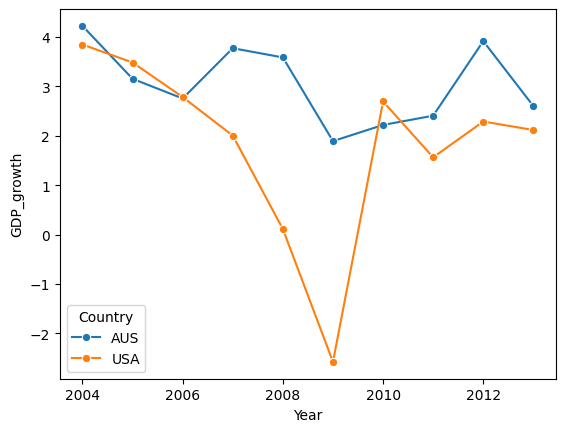

In [5]:
sns.lineplot(
            data=chart_panel_df,
            x='Year',
            y='GDP_growth',
            hue='Country',
            marker='o'
        )

### checking for parallel trends assumption
plotted trends of audio features over time, visually inspected graph before recession to determine if audio features of songs followed similar trends

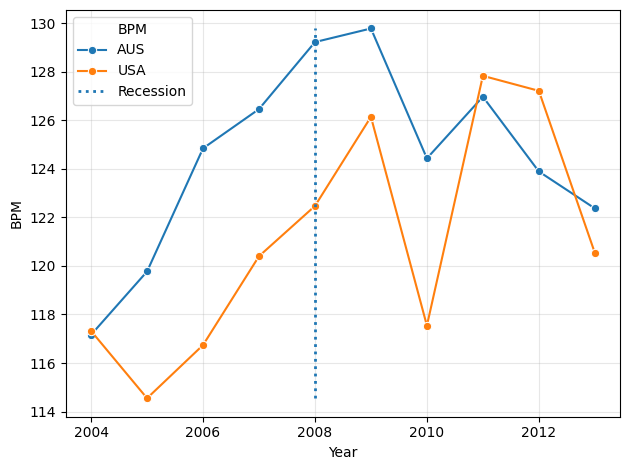

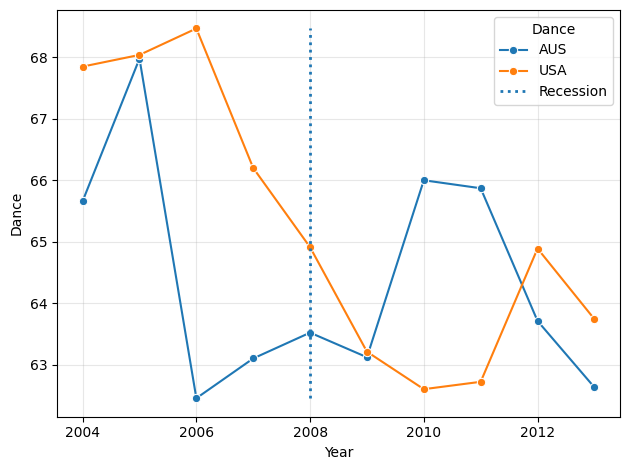

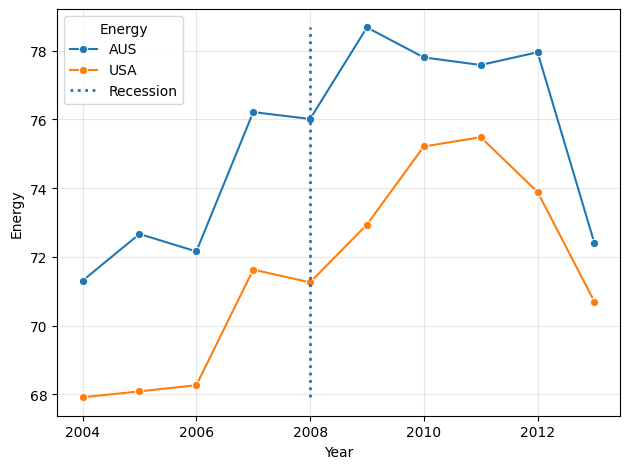

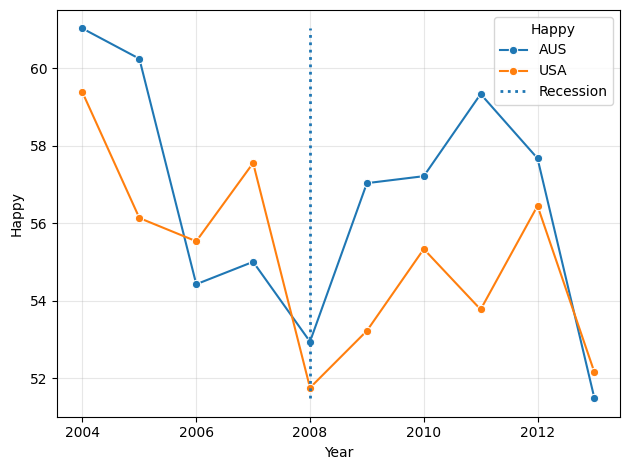

In [6]:
def plot_charts(audio_feature_list):
    for audio_feature in audio_feature_list:
        sns.lineplot(
            data=chart_panel_df,
            x='Year',
            y=audio_feature,
            hue='Country',
            marker='o'
        )
        plt.vlines(x=2008, ymin=chart_panel_df[audio_feature].min(), ymax=chart_panel_df[audio_feature].max(), linestyle=":", lw=2, label="Recession")
        plt.legend(title=audio_feature)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_charts(columns_to_read)

In [7]:
def run_did(audio_feature, covariates):
    # Create the interaction term for DiD
    chart_panel_df["did"] = chart_panel_df["Treat_Grp"] * chart_panel_df["post_recession"]

    # Run a fixed-effects (entity & time) DiD regression using OLS with dummy FE
    # Entity FE: C(country)
    # Time FE: C(year)
    covariate_string = '+'.join(covariates)
    model = smf.ols(
        formula=f"{audio_feature} ~ did + C(Country) + C(Year) + {covariate_string}",
        data=chart_panel_df
    ).fit(cov_type="HC1")  # HC1 = robust (heteroskedasticity-consistent)

    print(model.summary())

for i in columns_to_read:
    run_did(i, covariates)

                            OLS Regression Results                            
Dep. Variable:                    BPM   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     59.01
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           7.63e-06
Time:                        10:20:17   Log-Likelihood:                -39.371
No. Observations:                  20   AIC:                             104.7
Df Residuals:                       7   BIC:                             117.7
Df Model:                          12                                         
Covariance Type:                  HC1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           118.5196      4.61